
## Task - 1: Implementation of MCP Neurons:

In [1]:
import numpy as np

def MCP_Neurons_AND(X1, X2, T):
    """
    This functions implements basic AND operations with MCP Neuron for two inputs.
    Arguments:

    Inputs:
        X1 (1 nd array): An array of binary values.
        X2 (1 nd array): An array of binary values.

    Output:
        state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
    """
    assert len(X1) == len(X2)

    ### YOUR CODE HERE ###
    # Perform an element wise addition of two input arrays stored in a new array(list):
    # Create a new array to put all the prediction let’s name that a state_neuron.
    state_neuron = [];

    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
    for i in range(len(X1)):
        total = X1[i] + X2[i]

        if(total > T):
            state_neuron.append(1)
        else:
            state_neuron.append(0)
        
    return state_neuron

### testing `MCP_Neurons_AND`

In [2]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2 # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 0]


### implementation of `mcp_neurons_or`

In [3]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.

    Arguments:
        Inputs:
        X1 (1D array): An array of binary values.
        X2 (1D array): An array of binary values.

    Output:
        state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)

    ### YOUR CODE HERE ###
    # Perform an element wise addition of two input arrays stored in a new array(list):
    # Create a new array to put all the prediction let's name that a state_neuron.
    state_neuron = []

    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
    for i in range(len(X1)):
        total = X1[i] + X2[i]

        if(total > T):
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

### testing the function

In [4]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_xor = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_xor}")

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 0, 0, 1]


### Question - 1: List out all the limitations of MCP - Neurons.
Ans:  Following are the limitations of MCP-Neuron:

- It only works for linearly separable data.
- Prone to overfitting 
- Hard to interpret (black-box) 

### Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.
- `{Can you devise a if else rules.}`
Ans:  yes following is the implementation of XOR using MCP Neuron 

##  implement XOR using MCP neuron

In [5]:
def mcp_neurons_xor(X1, X2):
    """
    This function implements basic XOR operations with MCP Neuron for two inputs.

    Arguments:
        Inputs:
        X1 (1D array): An array of binary values.
        X2 (1D array): An array of binary values.

    Output:
        state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert(len(X1) == len(X2))

    state_neuron = []

    for i in range(len(X1)):
        total = X1[i] + X2[i];
        
        or_result = 1 if total >= 1 else 0
        nand_result = 1 if total < 2 else 0

        if or_result == 1 and nand_result == 1:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


## testing XOR mcp neuron

In [6]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_xor = mcp_neurons_xor(X1, X2)

# Print the result
print(f"Output of XOR gate for inputs {X1} and {X2}: {result_xor}")

Output of XOR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1]: [0, 1, 1, 0]


# implementation of 0 Vs. 1 Classification.

## import the libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load the dataset

In [8]:
# Load the dataset
df_0_1 = pd.read_csv("./dataset/mnist_0_and_1.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


## Questions

### Question - 1: What does the shape of X represent?
Ans: The shape of X here represents the number of samples x number of features.

### Question - 2: What does the shape of y represent?
Ans: The shape of y here represents the number of labels.

## viewing dataset

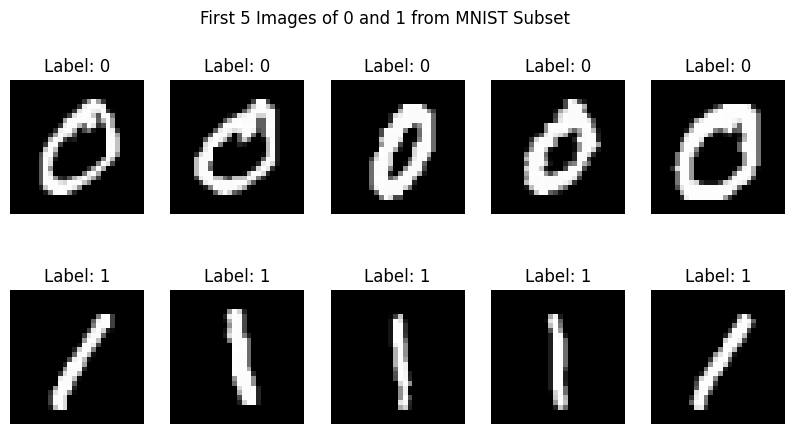

In [9]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Initialize the weights and other consts

In [10]:
# Initialize weights and bias
weights = np.zeros(X.shape[1]) #  for each col ? 
bias = 0
learning_rate = 0.1
epochs = 100

## Questions

### Question - 3: What does the weights array represent in this context?
- Ans: The weights array represents coefficients assigned to each feature (pixel). 

### Question - 4: Why are we initializing the weights to zero? What effect could this have on the training process?
- Ans: We are initializing the weights to zero because we want an simple initial starting point. The effect it might have is if the real weights are much more then it might take more epochs to train.

## making a decision function

In [11]:
def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    #####Your Code Here############  
    # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all


## implement perceptron learning

In [12]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    # Step 3: Perceptron Learning Algorithm

    # Your Code here#
    for i in range(epochs):
        conv_flag = True

        for i, sample in enumerate(X): 
            # for each training sample

            y_i = y[i]
            y_pred = decision_function(sample, weights, bias)

            if y_pred != y_i:
                error = y_i - y_pred 

                weights += learning_rate * error * sample
                bias += learning_rate * error 

                conv_flag = False


        if conv_flag:
            break 

    y_pred_all = decision_function(X, weights=weights, bias=bias)
    accuracy = np.mean(y_pred_all == y)

    return weights, bias, accuracy

## Questions

### Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?
- Ans: the given line is the weighted sum of inputs and bias. It is later used to decide the prediction (0 or 1).

### Question - 6: What happens when the prediction is wrong? How are the weights and bias updated?
- Ans: if the prediction is  wrong the weights and bias are updated to reduce the error.  Weights and bias are updated according to the perceptron update formula as given:
    - `w = w + η (y - ŷ) X_i`
    - `b = b + η (y - ŷ)`

### Question - 7:Why is the final accuracy important, and what do you expect it to be?
- Ans:  The final accuracy shows how the model performs on the data. It is expected to be high on simple data like binary classificatin (0 or 1).

### training perceptron

In [13]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias);
print(f"Final accuracy is", accuracy);

Final accuracy is 1.0


### visualization

In [14]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)
# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")
# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]): # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


# Perceptron for 3 or 5 classification

## get the data

In [15]:
# Load the dataset
df_2_3 = pd.read_csv("./dataset/mnist_3_and_5.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_2_3.drop(columns=["label"]).values  # 784 pixels
y = df_2_3["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


## making decision function for 3 or 5

In [16]:
def decision_function_two(X, weights, bias):
    predictions = (X @ weights) + bias;
    y_pred_all = np.where(predictions >= 0, 5, 3)
    return y_pred_all

## implementation of perceptron learning

### define consts 

In [17]:
# Initialize weights and bias
weights = np.zeros(X.shape[1]) #  for each col ? 
bias = 0
learning_rate = 0.1
epochs = 100

In [18]:
def train_perceptron_two(X, y, weights, bias, eta = 0.1, epochs = 100):

    for i in range(epochs):
        conv_flag = True
        for  i, sample in enumerate(X):
            y_i =  y[i];
            y_pred = decision_function_two(sample, weights, bias)
            if y_pred != y_i: 
                error = y_i - y_pred 
                weights += learning_rate * error * sample

                bias += learning_rate * error 

                conv_flag = False

        if conv_flag:
            break

    y_pred_all = decision_function_two(X, weights=weights, bias=bias)
    accuracy = np.mean(y_pred_all == y)

    return weights, bias, accuracy

### train perceptron 

In [19]:
weights_two, bias_two, accuracy_two = train_perceptron_two(X, y, weights, bias);
print(f"Final accuracy is", accuracy_two);

Final accuracy is 0.986866107260124


### visualization

Final Accuracy: 0.9869


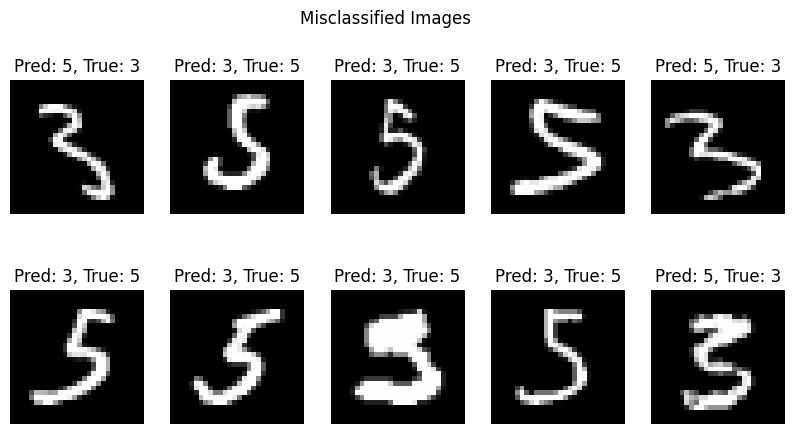

In [20]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 5, 3)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")
# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]): # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")